# County Demographics, Income, and Voting (MDST Project Rebuild)

My Michigan Data Science Team project using `MDST_cleaned_dataset.csv`.
Each county has Census/ACS demographics merged with 2020 county-level presidential results.

In [ ]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

raw = pd.read_csv("MDST_cleaned_dataset.csv")
print("Rows:", len(raw))
print("Unique counties (CensusId):", raw.CensusId.nunique())
print("Unique states (incl. DC):", raw.State.nunique())

Rows: 19165
Unique counties (CensusId): 3025
Unique states (incl. DC): 49


In [ ]:
votes = raw.pivot_table(index="CensusId", columns="party", values="total_votes", aggfunc="sum", fill_value=0)
all_votes = raw.groupby("CensusId").total_votes.sum().rename("votes_all")

counties = raw.drop_duplicates("CensusId").set_index("CensusId")
counties = counties.drop(columns=["state", "county", "candidate", "party", "total_votes", "won"])
counties = counties.join(all_votes).join(votes[["DEM", "REP"]])
counties["dem_share"] = counties.DEM / (counties.DEM + counties.REP)
counties["winner"] = np.where(counties.DEM > counties.REP, "Biden", "Trump")

def majority_group(r):
    for g in ["White", "Black", "Hispanic", "Native", "Asian"]:
        if r[g] >= 50:
            return f"{g}-majority"
    return "No majority"
counties["group"] = counties.apply(majority_group, axis=1)

print(counties.shape)
counties[["State", "County", "TotalPop", "Income", "Poverty", "Asian", "dem_share", "winner", "group"]].head()

(3025, 42)


,State,County,TotalPop,Income,Poverty,Asian,dem_share,winner,group
CensusId,,,,,,,,,
1001,Alabama,Autauga,55221,51281.0,12.9,1.0,0.274423,Trump,White-majority
1003,Alabama,Baldwin,195121,50254.0,13.4,0.7,0.227317,Trump,White-majority
1005,Alabama,Barbour,26932,32964.0,26.7,0.4,0.461391,Trump,No majority
1007,Alabama,Bibb,22604,38678.0,16.8,0.1,0.208811,Trump,White-majority
1009,Alabama,Blount,57710,45813.0,16.7,0.1,0.096523,Trump,White-majority


## 1. Racial income disparities across counties

                   counties  median_income  median_poverty  \
group                                                        
White-majority         2691        45471.0           15.30   
No majority             143        47725.0           19.30   
Hispanic-majority        86        41670.0           20.65   
Native-majority          18        33125.5           35.60   
Black-majority           87        30767.0           28.00   

                   median_child_poverty  
group                                    
White-majority                    21.50  
No majority                       26.50  
Hispanic-majority                 29.05  
Native-majority                   46.10  
Black-majority                    42.40  


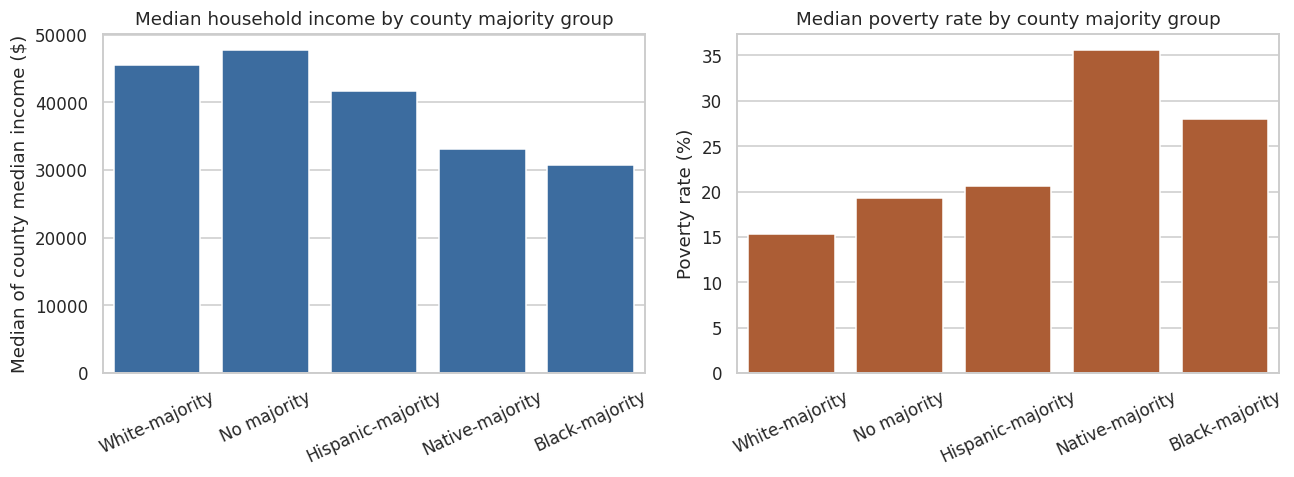

In [ ]:
order = ["White-majority", "No majority", "Hispanic-majority", "Native-majority", "Black-majority"]
summary = (counties.groupby("group")
           .agg(counties=("Income", "size"),
                median_income=("Income", "median"),
                median_poverty=("Poverty", "median"),
                median_child_poverty=("ChildPoverty", "median"))
           .loc[order])
print(summary)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
sns.barplot(x=summary.index, y=summary.median_income, ax=ax[0], color="#2b6cb0")
ax[0].set_title("Median household income by county majority group")
ax[0].set_ylabel("Median of county median income ($)")
sns.barplot(x=summary.index, y=summary.median_poverty, ax=ax[1], color="#c05621")
ax[1].set_title("Median poverty rate by county majority group")
ax[1].set_ylabel("Poverty rate (%)")
for a in ax:
    a.set_xlabel("")
    a.tick_params(axis="x", rotation=25)
plt.tight_layout(); plt.show()

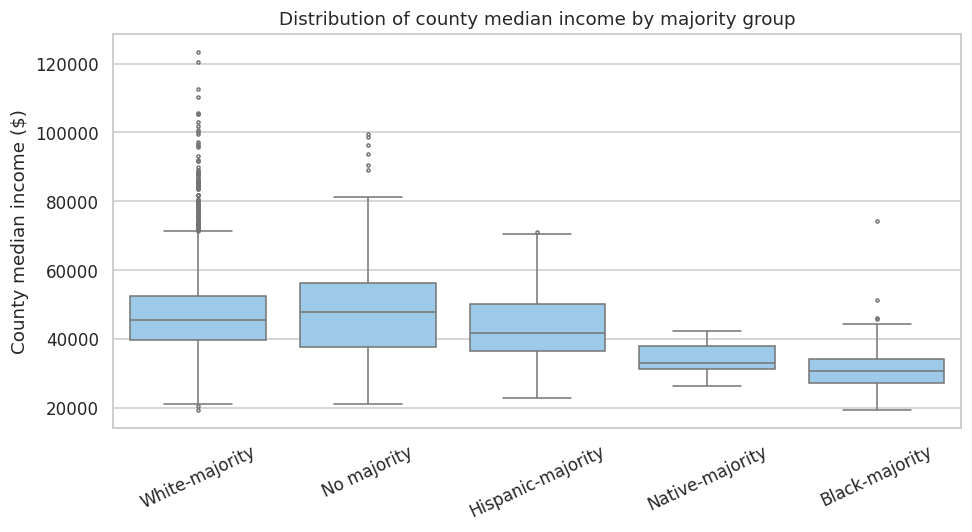

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=counties, x="group", y="Income", order=order, color="#90cdf4", fliersize=2, ax=ax)
ax.set_title("Distribution of county median income by majority group")
ax.set_xlabel(""); ax.set_ylabel("County median income ($)")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout(); plt.show()

## 2. Where Asian population share is high, and how those counties look

Because the data only has an aggregate Asian share, this section shows how counties differ by that share.
It cannot show differences between Asian American subgroups.

                counties  median_income  professional_pct  dem_share
asian_quintile                                                      
(-0.001, 0.2]        791        40657.0              28.4   0.227651
(0.2, 0.4]           521        42897.0              28.1   0.256640
(0.4, 0.7]           585        44103.0              29.4   0.283539
(0.7, 1.4]           535        46945.0              31.3   0.350538
(1.4, 41.6]          593        52446.0              36.0   0.495147


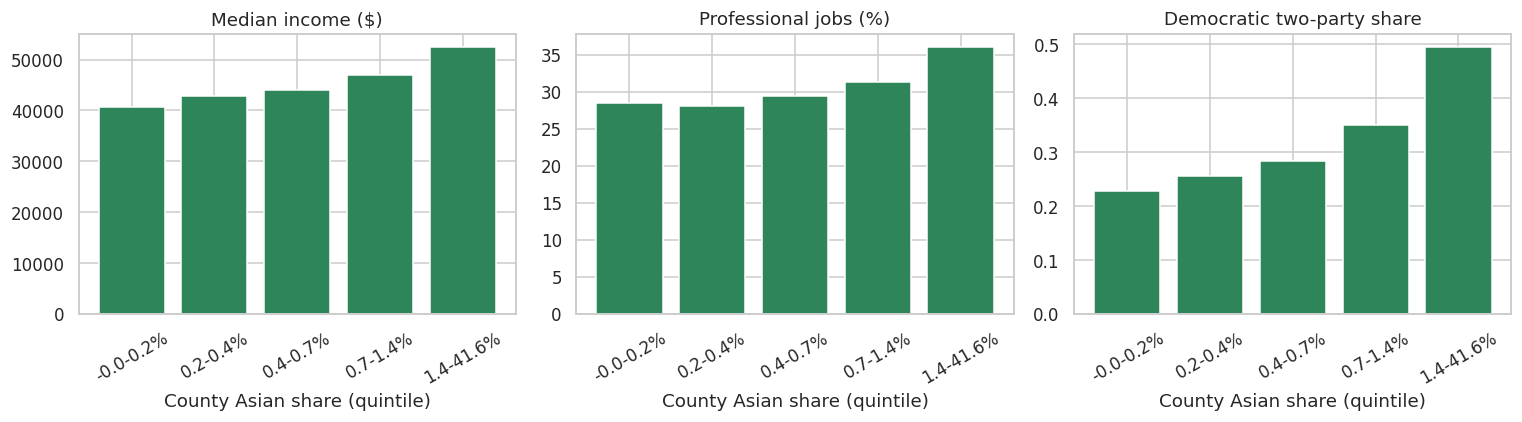

              Asian  Income  Professional  Poverty  dem_share
Asian          1.00    0.44          0.41    -0.13       0.46
Income         0.44    1.00          0.61    -0.75       0.23
Professional   0.41    0.61          1.00    -0.40       0.33
Poverty       -0.13   -0.75         -0.40     1.00       0.13
dem_share      0.46    0.23          0.33     0.13       1.00


In [ ]:
counties["asian_quintile"] = pd.qcut(counties.Asian, 5, duplicates="drop")
q = (counties.groupby("asian_quintile", observed=True)
     .agg(counties=("Income", "size"),
          median_income=("Income", "median"),
          professional_pct=("Professional", "median"),
          dem_share=("dem_share", "median")))
print(q)

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
labels = [f"{i.left:.1f}-{i.right:.1f}%" for i in q.index]
for a, col, title in zip(ax, ["median_income", "professional_pct", "dem_share"],
                         ["Median income ($)", "Professional jobs (%)", "Democratic two-party share"]):
    a.bar(labels, q[col], color="#2f855a")
    a.set_title(title); a.set_xlabel("County Asian share (quintile)")
    a.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

print(counties[["Asian", "Income", "Professional", "Poverty", "dem_share"]].corr().round(2))

In [ ]:
top = (counties.sort_values("Asian", ascending=False)
       [["State", "County", "TotalPop", "Asian", "Income", "dem_share"]].head(10))
top.round(3)

,State,County,TotalPop,Asian,Income,dem_share
CensusId,,,,,,
15003,Hawaii,Honolulu,984178,41.6,74460.0,0.637
15007,Hawaii,Kauai,69691,33.6,65101.0,0.647
6075,California,San Francisco,840763,33.5,81294.0,0.870
6085,California,Santa Clara,1868149,33.5,96310.0,0.742
6001,California,Alameda,1584983,27.5,75619.0,0.819
15009,Hawaii,Maui,160863,26.7,66476.0,0.681
6081,California,San Mateo,748731,26.2,93623.0,0.794
36081,New York,Queens,2301139,24.2,57720.0,0.728
34023,New Jersey,Middlesex,830300,23.2,79593.0,0.612


## 3. County-level patterns: income, race, and voting

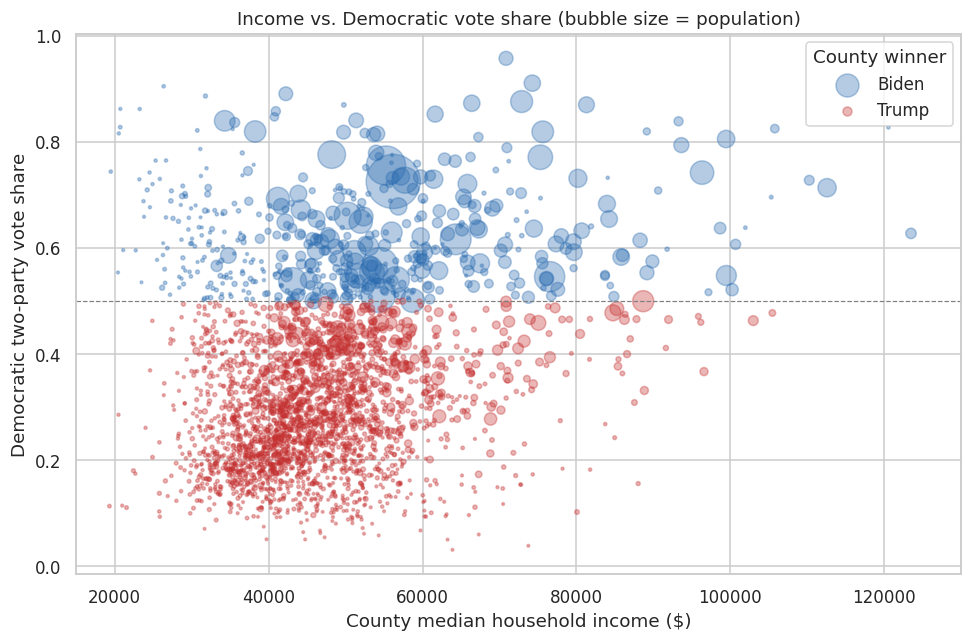

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))
colors = {"Biden": "#2b6cb0", "Trump": "#c53030"}
for w, g in counties.groupby("winner"):
    ax.scatter(g.Income, g.dem_share, s=g.TotalPop / 8000 + 3, alpha=0.35, c=colors[w], label=w)
ax.axhline(0.5, color="gray", lw=0.8, ls="--")
ax.set_xlim(15000, 130000)
ax.set_xlabel("County median household income ($)")
ax.set_ylabel("Democratic two-party vote share")
ax.set_title("Income vs. Democratic vote share (bubble size = population)")
ax.legend(title="County winner", markerscale=0.6)
plt.tight_layout(); plt.show()

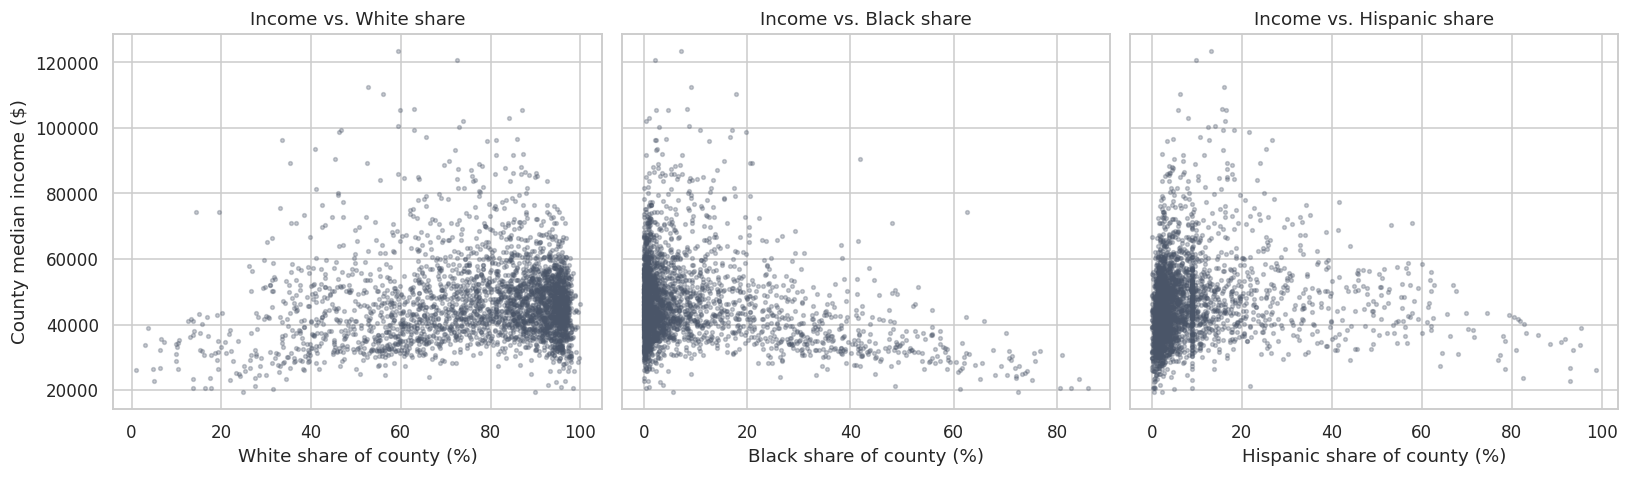

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for a, col in zip(ax, ["White", "Black", "Hispanic"]):
    a.scatter(counties[col], counties.Income, s=6, alpha=0.3, color="#4a5568")
    a.set_xlabel(f"{col} share of county (%)")
    a.set_title(f"Income vs. {col} share")
ax[0].set_ylabel("County median income ($)")
plt.tight_layout(); plt.show()

## 4. State-level view

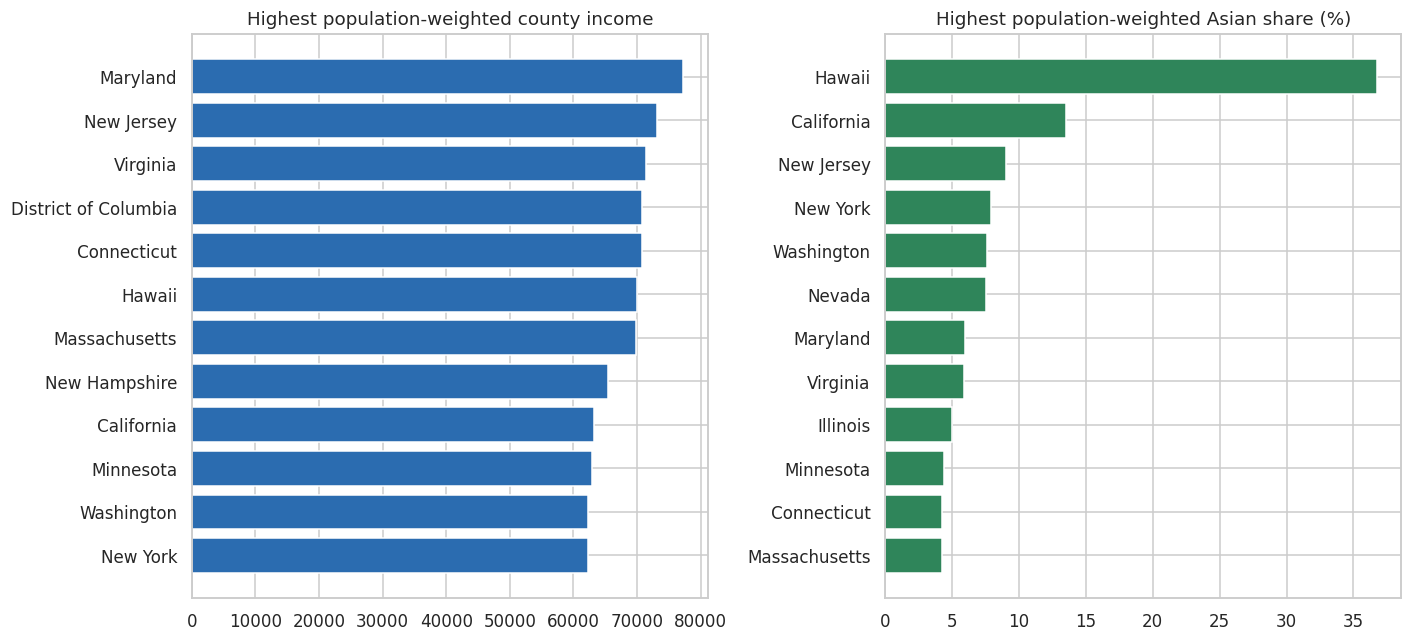

In [ ]:
def wavg(g, col):
    return np.average(g[col], weights=g.TotalPop)

states = (counties.groupby("State")
          .apply(lambda g: pd.Series({
              "counties": len(g),
              "population": g.TotalPop.sum(),
              "income_pop_weighted": wavg(g, "Income"),
              "asian_pct": wavg(g, "Asian"),
              "dem_share": g.DEM.sum() / (g.DEM.sum() + g.REP.sum())}), include_groups=False)
          .reset_index())

fig, ax = plt.subplots(1, 2, figsize=(13, 6))
s1 = states.sort_values("income_pop_weighted").tail(12)
ax[0].barh(s1.State, s1.income_pop_weighted, color="#2b6cb0")
ax[0].set_title("Highest population-weighted county income")
s2 = states.sort_values("asian_pct").tail(12)
ax[1].barh(s2.State, s2.asian_pct, color="#2f855a")
ax[1].set_title("Highest population-weighted Asian share (%)")
plt.tight_layout(); plt.show()

## 5. Interactive dashboard
Saved as `county_dashboard.html` (hover for county names, filter by legend).

In [ ]:
plot_df = counties.reset_index().copy()
plot_df["label"] = plot_df.County + ", " + plot_df.State
fig = px.scatter(
    plot_df, x="Income", y="dem_share", size="TotalPop", color="group",
    hover_name="label", hover_data={"Asian": ":.1f", "Poverty": ":.1f", "TotalPop": ":,", "Income": ":,", "dem_share": ":.2f"},
    size_max=40, opacity=0.6,
    labels={"Income": "Median household income ($)", "dem_share": "Democratic two-party share", "group": "Majority group"},
    title="County income vs. Democratic vote share")
fig.add_hline(y=0.5, line_dash="dash", line_color="gray")
fig.update_layout(height=650, template="plotly_white")
fig.write_html("county_dashboard.html", include_plotlyjs=True)
